# Лабораторна робота №3
## Дослідження алгоритмів сортування
Виконав: студент групи КН-25-1 Марусіченко А. О.

**Мета:** засвоїти аналіз складності алгоритмів як технологію на прикладі алгоритмів сортування методами включення та обміну.

### Сортування вставлянням (Insertion Sort)
Алгоритм проходить по масиву зліва направо та вставляє кожний елемент у вже відсортовану частину.

Кращий випадок: масив уже відсортований. $T(n) = O(n)$

Середній випадок: $T(n) = O(n^2)$

Найгірший випадок: масив відсортований у зворотному порядку. $T(n) = O(n^2)$

### Сортування бульбашкою (Bubble Sort)
Алгоритм багаторазово порівнює сусідні елементи та міняє їх місцями.

Кращий випадок: якщо масив уже відсортований, за допомогою прапорця (оптимізації) можна зупинити алгоритм після першого проходу. $T(n) = O(n)$

Середній випадок: $T(n) = O(n^2)$

Найгірший випадок: $T(n) = O(n^2)$

### На Python алгоритм сортування методом бульбашки

In [9]:
import time
import random

def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        swapped = False
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True
        if not swapped:
            break
    return arr

def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and key < arr[j]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key
    return arr

sizes = [5, 10, 50, 100, 500, 1000, 2000, 3000, 4000, 5000]

print(f"{'Розмір (n)':<12} | {'Бульбашка Tbubble(n)':<22} | {'Вставляння Tinsert(n)':<22}")
print("-" * 62)

for n in sizes:
    base_array = [random.randint(1, 100000) for _ in range(n)]
    
    arr_b = base_array.copy()
    arr_i = base_array.copy()
  
    start = time.perf_counter()
    bubble_sort(arr_b)
    end = time.perf_counter()
    t_bubble = end - start
    
    start = time.perf_counter()
    insertion_sort(arr_i)
    end = time.perf_counter()
    t_insert = end - start
    
    print(f"{n:<12} | {t_bubble:<22.6f} | {t_insert:<22.6f}")

Розмір (n)   | Бульбашка Tbubble(n)   | Вставляння Tinsert(n) 
--------------------------------------------------------------
5            | 0.000011               | 0.000006              
10           | 0.000014               | 0.000008              
50           | 0.000246               | 0.000132              
100          | 0.001065               | 0.000566              
500          | 0.032557               | 0.016515              
1000         | 0.113292               | 0.058021              
2000         | 0.490861               | 0.219548              
3000         | 1.077930               | 0.516137              
4000         | 1.873157               | 0.895778              
5000         | 3.394045               | 1.525543              


### Дослідити реальний час виконання обох алгоритмів на Python і побудувати графіки залежностей

Розмір (n)   | Бульбашка Tbubble(n)   | Вставляння Tinsert(n) 
--------------------------------------------------------------
5            | 0.000007               | 0.000004              
10           | 0.000013               | 0.000008              
50           | 0.000267               | 0.000139              
100          | 0.001077               | 0.000661              
500          | 0.035139               | 0.014142              
1000         | 0.108374               | 0.053076              
2000         | 0.471892               | 0.222896              
3000         | 1.050464               | 0.521280              
4000         | 1.966101               | 0.937711              
5000         | 3.049970               | 1.482787              


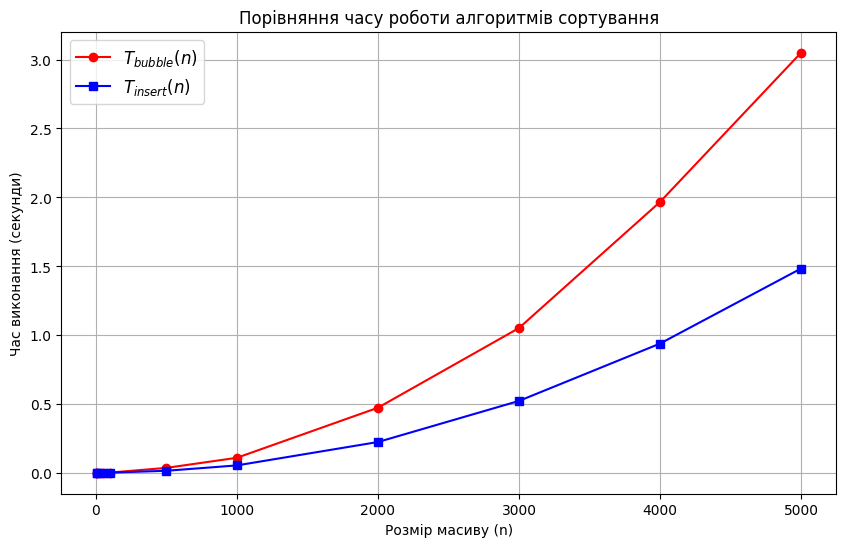

In [11]:
import time
import random
import matplotlib.pyplot as plt  

def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        swapped = False
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True
        if not swapped:
            break
    return arr

def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and key < arr[j]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key
    return arr

n_values = [5, 10, 50, 100, 500, 1000, 2000, 3000, 4000, 5000]
t_bubble = []
t_insert = []

print(f"{'Розмір (n)':<12} | {'Бульбашка Tbubble(n)':<22} | {'Вставляння Tinsert(n)':<22}")
print("-" * 62)

for n in n_values:
    original_arr = [random.randint(1, 100000) for _ in range(n)]
    
    arr_b = original_arr.copy()
    arr_i = original_arr.copy()

    start = time.perf_counter()
    bubble_sort(arr_b)
    end = time.perf_counter()
    duration_b = end - start
    t_bubble.append(duration_b)
    
    start = time.perf_counter()
    insertion_sort(arr_i)
    end = time.perf_counter()
    duration_i = end - start
    t_insert.append(duration_i)
    
    print(f"{n:<12} | {duration_b:<22.6f} | {duration_i:<22.6f}")


plt.figure(figsize=(10, 6))
plt.plot(n_values, t_bubble, label='$T_{bubble}(n)$', color='red', marker='o', linestyle='-')
plt.plot(n_values, t_insert, label='$T_{insert}(n)$', color='blue', marker='s', linestyle='-')

plt.title('Порівняння часу роботи алгоритмів сортування')
plt.xlabel('Розмір масиву (n)')
plt.ylabel('Час виконання (секунди)')
plt.grid(True)
plt.legend(loc='upper left', fontsize=12)
plt.show()

**Висновок:** засвоїла аналіз складності алгоритмів як технологію на прикладі алгоритмів сортування методами включення та обміну.

### Контрольні питання

**1. Що таке О-нотація і чим вона відрізняється від $\Omega$-нотації?**
* **Відповідь:** $O$-нотація показує найгірший випадок (максимальний час роботи коду), а $\Omega$-нотація — найкращий випадок (мінімальний час).

**2. Яку часову складність має алгоритм сортування вставлянням для відсортованого масиву?**
* **Відповідь:** Лінійну складність **$O(n)$**, тому що елементи вже стоять на своїх місцях і код просто перевіряє їх за один прохід.

**3. Надати визначення ефективного алгоритму.**
* **Відповідь:** Це алгоритм, який вирішує задачу за мінімальний час і витрачає якнайменше оперативної пам'яті комп'ютера.

**4. Пояснити поняття головного параметра (розміру) завдання.**
* **Відповідь:** Це обсяг вхідних даних (позначається як $n$), від якого залежить швидкість роботи коду. У нас це кількість елементів у масиві.

**5. $F(N) = N^3 + 7N^2 - 14N$. Як записати асимптотичну складність у О-нотації?**
* **Відповідь:** **$O(N^3)$**, тому що при великих даних враховується лише доданок із найбільшим степенем, а решта відкидається.